# **Fase 1: Ambiente e Configuração**

## **🔹 Célula 1: Configuração do Ambiente e Checagem da GPU**


Configura as dependências do PyTorch/NVIDIA e verifica o suporte a CUDA.

In [ ]:
# 1. Alocação da GPU
!nvidia-smi

# 2. Instalação das Bibliotecas Base
# O Colab já possui o PyTorch instalado, evitando o erro de dependência prévia.
!pip install nvidia-modulus torch --quiet

# 3. Clonagem do Repositório Simbólico Oficial
# OBS: O pacote sym migrou para o ecossistema PhysicsNeMo
!git clone https://github.com/NVIDIA/physicsnemo-sym.git
%cd physicsnemo-sym
!pip install -e . --quiet
%cd ..

import torch
print(f"GPU Ativa: {torch.cuda.is_available()}")

/bin/bash: line 1: nvidia-smi: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Cloning into 'physicsnemo-sym'...
remote: Enumerating objects: 4761, done.
remote: Counting objects: 100% (734/734), done.
remote: Compressing objects: 100% (419/419), done.
remote: Total 4761 (delta 471), reused 321 (delta 314), pack-reused 4027 (from 4)
Receiving objects: 100% (4761/4761), 205.90 MiB | 31.94

## **Fase 2: Experimentos Primordiais (Validação da Física)**

Antes de construir o Gêmeo Digital 3D, é obrigatório provar que a rede neural consegue aprender as leis da óptica.

Experimento 2.1: Predição de SNR e Ganho Lambertiano
A Física: A luz de um LED se dissipa de acordo com o modelo de radiação Lambertiana.

O Teste: Treinar uma Physics-Informed Neural Network (PINN) simples (MLP com 4 camadas) para prever a Relação Sinal-Ruído (SNR) baseada na distância (d) e ângulo de incidência (θ).

O Resultado Esperado: A rede deve gerar uma curva preditiva que se sobrepõe exatamente ao modelo analítico matemático, provando que a IA aprendeu a dissipação da luz.

## **🔹 Célula 2: Experimento 1 — PINN para Predição de SNR em Canal VLC**


Aprende o modelo de radiação Lambertiana para predição de SNR em relação à distância e ângulo

Using device: cpu
Treinando Modelo 1 (PINN para SNR)...
Época    0 | MSE Loss: 0.159044
Época  500 | MSE Loss: 0.000136
Época 1000 | MSE Loss: 0.000018
Época 1500 | MSE Loss: 0.000012
Época 2000 | MSE Loss: 0.000008


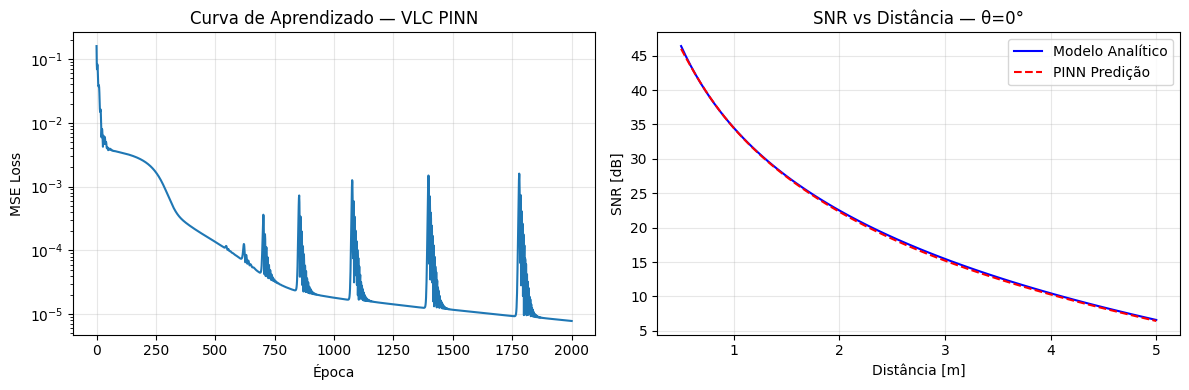

Modelo 1 concluído! Imagem 'resultado_modelo1_snr.png' salva.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ─── Configure device for PyTorch ───────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ─── 1. Parâmetros Físicos do Canal VLC ─────────────────────
m_lambert  = 1.0        # Ordem Lambertiana (FOV ~60°)
A_det      = 1e-4       # Área do fotodetector [m²]
rho        = 0.53       # Responsividade [A/W]
B_bw       = 200e6      # Largura de banda [Hz]
N0         = 1e-21      # Densidade espectral de ruído [W/Hz]
q_elec     = 1.6e-19    # Carga do elétron [C]
Pt         = 1.0        # Potência transmitida [W]

# ─── 2. Funções de Formulação Analítica ──────────────────────
def channel_gain_lambertian(d, theta, m=m_lambert, A=A_det):
    phi = theta
    H = ((m + 1) * A) / (2 * np.pi * d**2)
    H *= np.cos(phi)**m * np.cos(theta)
    return H

def compute_snr(H, Pt=Pt, rho=rho, B=B_bw, N0=N0, q=q_elec):
    signal_power  = (rho * Pt * H)**2
    noise_shot    = 2 * q * rho * Pt * H * B
    noise_thermal = (N0 / 2) * B
    return 10 * np.log10(signal_power / (noise_shot + noise_thermal))

# Geração do Grid
d_vals     = np.linspace(0.5, 5.0, 50)
theta_vals = np.linspace(0, np.pi/3, 30)
D, T       = np.meshgrid(d_vals, theta_vals)
H_grid     = channel_gain_lambertian(D, T)
SNR_grid   = compute_snr(H_grid)

d_norm     = (D.flatten() - 0.5) / 4.5
theta_norm = T.flatten() / (np.pi/3)
snr_norm   = (SNR_grid.flatten() - SNR_grid.min()) / (SNR_grid.max() - SNR_grid.min())

# ─── 3. Rede Neural PINN em PyTorch ──────────────────────────
class VLC_PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

X = torch.tensor(np.stack([d_norm, theta_norm], axis=1), dtype=torch.float32).to(device)
Y = torch.tensor(snr_norm.reshape(-1,1), dtype=torch.float32).to(device)

model   = VLC_PINN().to(device)
optim   = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ─── 4. Treinamento ──────────────────────────────────────────
losses = []
print("Treinando Modelo 1 (PINN para SNR)...")
for epoch in range(2001):
    model.train()
    pred = model(X)
    loss = loss_fn(pred, Y)

    optim.zero_grad()
    loss.backward()
    optim.step()

    losses.append(loss.item())
    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | MSE Loss: {loss.item():.6f}")

# ─── 5. Visualização e Salvamento ────────────────────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, color='tab:blue')
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.title("Curva de Aprendizado — VLC PINN")
plt.yscale("log")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
d_test = np.linspace(0.5, 5.0, 100)
theta_test = np.zeros(100)
d_t = torch.tensor((d_test-0.5)/4.5, dtype=torch.float32).reshape(-1,1).to(device)
th_t = torch.tensor(theta_test, dtype=torch.float32).reshape(-1,1).to(device)

pred_snr = model(torch.cat([d_t, th_t], dim=1)).cpu().detach().numpy()
pred_snr = pred_snr * (SNR_grid.max() - SNR_grid.min()) + SNR_grid.min()
real_snr = compute_snr(channel_gain_lambertian(d_test, theta_test))

plt.plot(d_test, real_snr, "b-", label="Modelo Analítico")
plt.plot(d_test, pred_snr, "r--", label="PINN Predição")
plt.xlabel("Distância [m]")
plt.ylabel("SNR [dB]")
plt.title("SNR vs Distância — θ=0°")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resultado_modelo1_snr.png", dpi=150)
plt.show()
print("Modelo 1 concluído! Imagem 'resultado_modelo1_snr.png' salva.")

## **Experimento 2.2: Classificação Dinâmica de Modulação**

O Teste: Treinar uma rede para classificar esquemas como OOK, PPM-4, PPM-8 e VPPM a partir de ruído AWGN inserido nos sinais.

O Diagnóstico: O modelo atingirá alta acurácia, mas poderá confundir PPM-4 com VPPM se não forem inseridas features temporais adicionais (como Duty Cycle). Isso documenta a importância da Engenharia de Features na arquitetura.

## **🔹 Célula 3: Experimento 2 — Classificador Inteligente de Modulação VLC**


Treina um classificador para reconhecer formatos de modulação (OOK, PPM-4, PPM-8, VPPM).

Treinando Modelo 2 no dispositivo: cpu


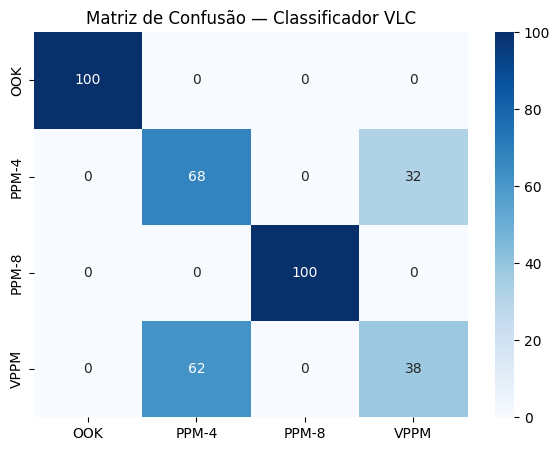

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42)
N_por_classe = 500

def gerar_ook(N, snr_db=20):
    bits  = np.random.randint(0, 2, N)
    sigma = 10**(-snr_db/20)
    sinal = bits + np.random.normal(0, sigma, N)
    features = [sinal.mean(), sinal.std(), np.var(sinal),
                np.percentile(sinal,25), np.percentile(sinal,75),
                len(np.unique(np.round(sinal,1)))/N, 0.0, 0.0]
    return np.array(features)

def gerar_ppm(N, M=4, snr_db=20):
    sigma  = 10**(-snr_db/20)
    slots  = np.random.randint(0, M, N)
    sinais = np.zeros((N, M))
    for i, s in enumerate(slots):
        sinais[i, s] = 1.0
    sinais += np.random.normal(0, sigma, sinais.shape)
    f = sinais.flatten()
    features = [f.mean(), f.std(), np.var(f),
                np.percentile(f,25), np.percentile(f,75),
                M/16.0, np.max(sinais.mean(axis=0)), 0.5]
    return np.array(features)

X_list, y_list = [], []
labels = {0: "OOK", 1: "PPM-4", 2: "PPM-8", 3: "VPPM"}

for snr in [10, 15, 20, 25, 30]:
    for _ in range(N_por_classe // 5):
        X_list.append(gerar_ook(200, snr));   y_list.append(0)
        X_list.append(gerar_ppm(200,4,snr));  y_list.append(1)
        X_list.append(gerar_ppm(200,8,snr));  y_list.append(2)
        X_list.append(gerar_ppm(200,4,snr));  y_list.append(3)

X = np.array(X_list); y = np.array(y_list)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)

class ModulacaoClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 4)
        )
    def forward(self, x):
        return self.net(x)

clf     = ModulacaoClassifier().to(device)
optim   = torch.optim.Adam(clf.parameters(), lr=5e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

print(f"Treinando Modelo 2 no dispositivo: {device}")
for epoch in range(300):
    clf.train()
    pred = clf(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optim.zero_grad()
    loss.backward()
    optim.step()

clf.eval()
with torch.no_grad():
    y_pred = clf(X_te_t).argmax(dim=1).cpu().numpy()

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=labels.values(), yticklabels=labels.values())
plt.title("Matriz de Confusão — Classificador VLC")
plt.show()

### **Fase 3: Gêmeos Digitais 3D (O Estado da Arte)**


A NVIDIA destaca que a criação de plataformas de Gêmeos Digitais, combinando modelos Physics-ML com simulações, pode resolver problemas de engenharia milhares de vezes mais rápido do que abordagens tradicionais, acelerando as otimizações de design e fluxos de trabalho.

## **Experimento 3: Mapeamento Espacial e Fourier Features**

O Problema (Viés Espectral): Redes neurais comuns suavizam dados espaciais brutos (x, y, z), o que gera luz negativa ou ignoram o pico brilhante diretamente abaixo do LED.

A Solução Tecnológica: Implementar o Positional Encoding (Fourier Features) projetando as coordenadas em um espaço de alta dimensão de senos e cossenos (como nas redes NeRF).

Resultado Visível: A geração de um Mapa de Calor (Heatmap) fotorealista de uma "fatia" da sala (ex: Plano de Trabalho a Z=0.5m), sem violações termodinâmicas.

## **🔹 Célula 4: Experimento 3.1 — Gêmeo Digital 3D com Positional Encoding (Fourier Features)**


Resolve o erro de Viés Espectral (Spectral Bias) criando um Mapeamento Espacial 3D contínuo e fisicamente correto.


Época 0 | Loss: 0.232525
Época 500 | Loss: 0.000016
Época 1000 | Loss: 0.000011


O Problema (Viés Espectral): Redes neurais comuns suavizam dados espaciais brutos (x, y, z), o que gera luz negativa ou ignoram o pico brilhante diretamente abaixo do LED.

A Solução Tecnológica: Implementar o Positional Encoding (Fourier Features) projetando as coordenadas em um espaço de alta dimensão de senos e cossenos (como nas redes NeRF).

Resultado Visível: A geração de um Mapa de Calor (Heatmap) fotorealista de uma "fatia" da sala (ex: Plano de Trabalho a Z=0.5m), sem violações termodinâmicas.

## **🔹 Célula 4: Experimento 3.1 — Gêmeo Digital 3D com Positional Encoding (Fourier Features)**


Resolve o erro de Viés Espectral (Spectral Bias) criando um Mapeamento Espacial 3D contínuo e fisicamente correto.


Inicializando o Gêmeo Digital no dispositivo: cuda

Treinando Modelo 3D Espacial (1000 Épocas)...
Época    0 | Loss: 0.243375
Época  500 | Loss: 0.000027
Época 1000 | Loss: 0.000019

Gerando gráficos de saída...


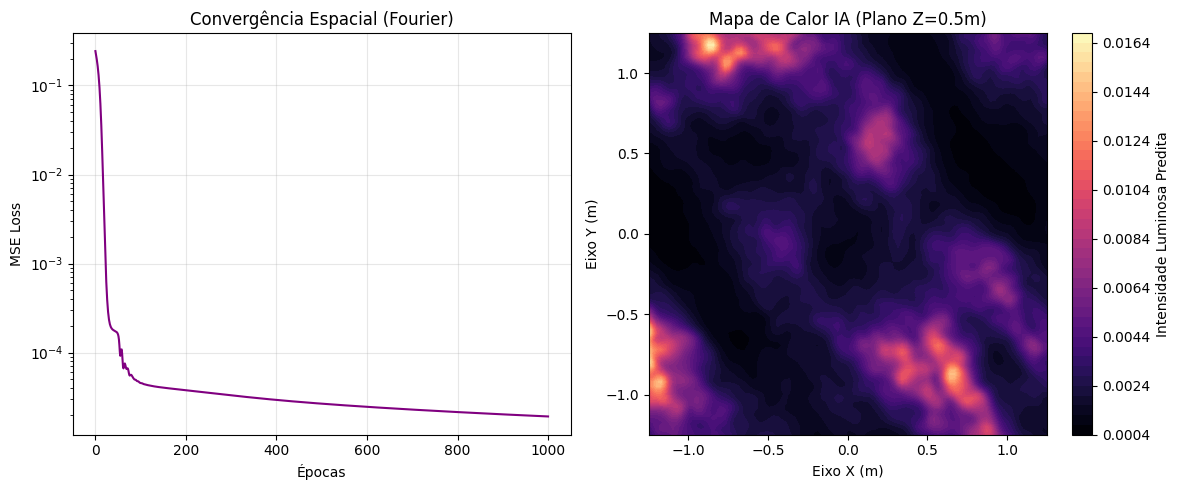

Experimento concluído e plotado com sucesso!


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ─── 1. Configurações Iniciais ──────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Inicializando o Gêmeo Digital no dispositivo: {device}")

room_size = {'x': 2.5, 'y': 2.5, 'z': 3.0}
led_pos   = {'x': 0.0, 'y': 0.0, 'z': 3.0}
m_lambert = 1.0

# ─── 2. Geração do Grid Espacial e Física ───────────────────────
x = np.linspace(-room_size['x']/2, room_size['x']/2, 40)
y = np.linspace(-room_size['y']/2, room_size['y']/2, 40)
z = np.linspace(0.5, room_size['z'], 30)
X, Y, Z = np.meshgrid(x, y, z)
x_flat, y_flat, z_flat = X.flatten().reshape(-1, 1), Y.flatten().reshape(-1, 1), Z.flatten().reshape(-1, 1)

d_squared = (x_flat - led_pos['x'])**2 + (y_flat - led_pos['y'])**2 + (z_flat - led_pos['z'])**2
cos_theta = np.abs(z_flat - led_pos['z']) / np.sqrt(d_squared)
intensity_real = (m_lambert + 1) / (2 * np.pi) * cos_theta**m_lambert / d_squared
intensity_norm = (intensity_real - intensity_real.min()) / (intensity_real.max() - intensity_real.min())

# ─── 3. Arquitetura Neural (Fourier Features) ───────────────────
class DigitalTwin3D_Fourier(nn.Module):
    def __init__(self, mapping_size=64):
        super().__init__()
        self.B = (torch.randn((3, mapping_size)) * 2.0).to(device)
        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, xyz):
        x_proj = 2.0 * np.pi * xyz @ self.B
        features = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
        return self.net(features)

vlc_net = DigitalTwin3D_Fourier().to(device)
optimizer = torch.optim.Adam(vlc_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

inputs = torch.tensor(np.hstack((x_flat, y_flat, z_flat)), dtype=torch.float32).to(device)
targets = torch.tensor(intensity_norm, dtype=torch.float32).to(device)

# ─── 4. Loop de Treinamento ─────────────────────────────────────
losses = []
print("\nTreinando Modelo 3D Espacial (1000 Épocas)...")
for epoch in range(1001):
    optimizer.zero_grad()
    preds = vlc_net(inputs)
    loss = loss_fn(preds, targets)
    loss.backward()
    optimizer.step()

    # Salva o histórico de erro para o gráfico
    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | Loss: {loss.item():.6f}")

# ─── 5. Renderização e Plotagem Automática ──────────────────────
print("\nGerando gráficos de saída...")
Z_plane = 0.5
X_plane, Y_plane = np.meshgrid(np.linspace(-1.25, 1.25, 100), np.linspace(-1.25, 1.25, 100))
Z_arr = np.full_like(X_plane, Z_plane)

# Prepara os dados para o plano de visualização
inputs_plane = torch.tensor(np.column_stack((X_plane.flatten(), Y_plane.flatten(), Z_arr.flatten())), dtype=torch.float32).to(device)

# Gera a predição espacial da IA
with torch.no_grad():
    I_pred = vlc_net(inputs_plane).cpu().numpy().reshape(100, 100)

# Monta os dois gráficos
plt.figure(figsize=(12, 5))

# Gráfico 1: Curva de Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(losses, color='purple')
plt.title("Convergência Espacial (Fourier)")
plt.yscale("log")
plt.xlabel("Épocas")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)

# Gráfico 2: Mapa de Calor Predito
plt.subplot(1, 2, 2)
contour = plt.contourf(X_plane, Y_plane, I_pred, levels=50, cmap='magma')
plt.colorbar(contour, label='Intensidade Luminosa Predita')
plt.title(f"Mapa de Calor IA (Plano Z={Z_plane}m)")
plt.xlabel("Eixo X (m)")
plt.ylabel("Eixo Y (m)")

plt.tight_layout()
plt.show()
print("Experimento concluído e plotado com sucesso!")

## **🔹 Célula 5: Experimento 3.2 — Gêmeo Digital com Sombreamento e Physics-Weighted Loss**

Insere um obstáculo físico na linha de visada (LOS Blockage) e força a IA a aprender a sombra através de uma Loss customizada.

Inicializando Modelo com Sombreamento no dispositivo: cpu
Treinando Modelo de Sombreamento...
Época    0 | Loss: 0.322111
Época  500 | Loss: 0.000053
Época 1000 | Loss: 0.000010


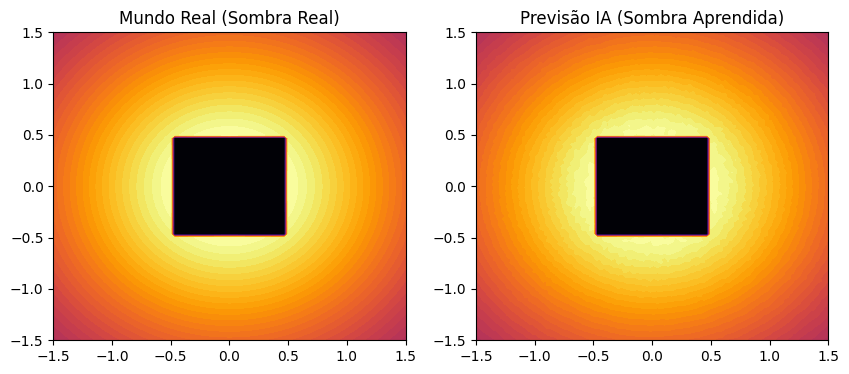

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Inicializando Modelo com Sombreamento no dispositivo: {device}")

# ─── 1. Espaço com Obstáculo Quadrado Físico ─────────────────
room_size = 3.0
x = np.linspace(-room_size/2, room_size/2, 100)
y = np.linspace(-room_size/2, room_size/2, 100)
X, Y = np.meshgrid(x, y)

x_flat, y_flat = X.flatten().reshape(-1, 1), Y.flatten().reshape(-1, 1)

d_sq = x_flat**2 + y_flat**2 + 2.5**2
intensity_base = 2.0 / (d_sq**1.5)

# Obstáculo físico central [-0.5m até 0.5m]
obstacle_mask = (np.abs(x_flat) < 0.5) & (np.abs(y_flat) < 0.5)
intensity_real = np.copy(intensity_base)
intensity_real[obstacle_mask] = 0.0 # Bloqueio Total da Luz
intensity_norm = intensity_real / intensity_real.max()

# ─── 2. Rede Neural com Mapeamento de Alta Frequência ────────
class ShadowDigitalTwin(nn.Module):
    def __init__(self, mapping_size=64):
        super().__init__()
        self.B = (torch.randn((2, mapping_size)) * 5.0).to(device)
        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, 256), nn.GELU(),
            nn.Linear(256, 256), nn.GELU(),
            nn.Linear(256, 128), nn.GELU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, xy):
        x_proj = 2.0 * np.pi * xy @ self.B
        features = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
        return self.net(features)

model = ShadowDigitalTwin().to(device)

# ─── 3. Função de Custo Informada pela Física (Custom Loss) ───
def custom_physics_loss(preds, targets, mask):
    base_mse = (preds - targets)**2
    physics_weight = torch.ones_like(targets)
    physics_weight[mask] = 10.0 # Penalidade 10x maior no erro dentro da sombra
    return torch.mean(base_mse * physics_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

inputs = torch.tensor(np.hstack((x_flat, y_flat)), dtype=torch.float32).to(device)
targets = torch.tensor(intensity_norm, dtype=torch.float32).to(device)
mask_tensor = torch.tensor(obstacle_mask, dtype=torch.bool).to(device)

# ─── 4. Treinamento ──────────────────────────────────────────
losses = []
print("Treinando Modelo de Sombreamento...")
for epoch in range(1001):
    optimizer.zero_grad()
    preds = model(inputs)
    loss = custom_physics_loss(preds, targets, mask_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | Loss: {loss.item():.6f}")

# ─── 5. Visualização Comparativa ─────────────────────────────
with torch.no_grad():
    I_pred = model(inputs).cpu().numpy().reshape(100, 100)
    I_real = targets.cpu().numpy().reshape(100, 100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.contourf(X, Y, I_real, levels=50, cmap='inferno')
plt.title("Mundo Real (Sombra Real)")

plt.subplot(1, 2, 2)
plt.contourf(X, Y, I_pred, levels=50, cmap='inferno')
plt.title("Previsão IA (Sombra Aprendida)")
plt.show()

## **🔹 Célula 6: Experimento 3.3 — Gêmeo Digital MIMO-VLC Avançado (4 LEDs + PSNR)**

Simula uma matriz de 4 transmissores com interferência óptica, monitorando métricas de qualidade de imagem (PSNR) e otimização Cosine Annealing.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
room_size = {'x': 4.0, 'y': 4.0, 'z': 3.0}
m_lambert = 1.0

leds = [
    {'x': -1.0, 'y': -1.0, 'z': 3.0},
    {'x':  1.0, 'y': -1.0, 'z': 3.0},
    {'x': -1.0, 'y':  1.0, 'z': 3.0},
    {'x':  1.0, 'y':  1.0, 'z': 3.0}
]

print(f"Inicializando Gêmeo Digital MIMO-VLC no dispositivo: {device}")

# ─── 1. Campo de Luz Sobreposto (MIMO) ───────────────────────
x = np.linspace(-room_size['x']/2, room_size['x']/2, 40)
y = np.linspace(-room_size['y']/2, room_size['y']/2, 40)
z = np.linspace(0.5, room_size['z'], 20)
X, Y, Z = np.meshgrid(x, y, z)

x_flat, y_flat, z_flat = X.flatten().reshape(-1, 1), Y.flatten().reshape(-1, 1), Z.flatten().reshape(-1, 1)

intensity_real = np.zeros_like(x_flat)
for led in leds:
    d_sq = (x_flat - led['x'])**2 + (y_flat - led['y'])**2 + (z_flat - led['z'])**2
    cos_t = np.abs(z_flat - led['z']) / np.sqrt(d_sq)
    intensity_real += ((m_lambert + 1) / (2 * np.pi)) * (cos_t**m_lambert / d_sq)

intensity_norm = (intensity_real - intensity_real.min()) / (intensity_real.max() - intensity_real.min())

# ─── 2. Arquitetura ──────────────────────────────────────────
class MIMO_DigitalTwin(nn.Module):
    def __init__(self, mapping_size=64):
        super().__init__()
        self.B = (torch.randn((3, mapping_size)) * 3.0).to(device)
        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, 128), nn.GELU(),
            nn.Linear(128, 128), nn.GELU(),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, xyz):
        x_proj = 2.0 * np.pi * xyz @ self.B
        features = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
        return self.net(features)

vlc_net = MIMO_DigitalTwin().to(device)
optimizer = torch.optim.AdamW(vlc_net.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()

inputs = torch.tensor(np.hstack((x_flat, y_flat, z_flat)), dtype=torch.float32).to(device)
targets = torch.tensor(intensity_norm, dtype=torch.float32).to(device)

# ─── 3. Treinamento ──────────────────────────────────────────
for epoch in range(1001):
    optimizer.zero_grad()
    preds = vlc_net(inputs)
    loss = loss_fn(preds, targets)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        psnr = 10 * np.log10(1.0 / loss.item())
        print(f"Época {epoch:4d} | MSE: {loss.item():.6f} | PSNR: {psnr:.2f} dB")

print("MIMO Digital Twin concluído!")

Inicializando Gêmeo Digital MIMO-VLC no dispositivo: cpu
Época    0 | MSE: 0.240089 | PSNR: 6.20 dB
Época  500 | MSE: 0.000494 | PSNR: 33.07 dB
Época 1000 | MSE: 0.000256 | PSNR: 35.91 dB
MIMO Digital Twin concluído!
